In [1]:
!pip install geopy matplotlib pandas -q

In [2]:
import pandas as pd

df = pd.read_csv('/content/Chicago Health Atlas Data Download - Community areas.csv', skiprows=[1,2,3,4])

In [3]:
print(df.columns)

Index(['Layer', 'Name', 'GEOID', 'Population', 'Longitude', 'Latitude',
       'LEQ_2020-2024', 'CIP_2010-2020', 'PCT-W_2020-2024', 'POP_2020-2024',
       'NHI_2023', 'HCSOBP_2023-2024', 'HCSOB_2023-2024', 'HCSHYTP_2023-2024',
       'HCSHYT_2023-2024', 'HCSDIA_2023-2024', 'HCSDIAP_2023-2024'],
      dtype='object')


In [4]:
# Initial Diagnostic

print(df.shape)
print(df.dtypes)

# missing values per column
print(df.isna().sum())

# Duplicates
print("Duplicated Columns:", df.duplicated().sum())
print("Name duplicates:", df['Name'].duplicated().sum())
print("GEOID duplicates:", df['GEOID'].duplicated().sum())

# Column Ranges in %
pct_cols = ['LEQ_2020-2024', 'PCT-W_2020-2024', 'NHI_2023',
            'HCSOBP_2023-2024', 'HCSHYTP_2023-2024', 'HCSDIAP_2023-2024']
for col in pct_cols:
    print(col, "min:", df[col].min(), "max:", df[col].max())

# Negative or 0 values
print("Population <= 0:", (df['Population'] <= 0).sum())

(77, 17)
Layer                 object
Name                  object
GEOID                  int64
Population             int64
Longitude            float64
Latitude             float64
LEQ_2020-2024        float64
CIP_2010-2020        float64
PCT-W_2020-2024      float64
POP_2020-2024        float64
NHI_2023             float64
HCSOBP_2023-2024     float64
HCSOB_2023-2024      float64
HCSHYTP_2023-2024    float64
HCSHYT_2023-2024     float64
HCSDIA_2023-2024     float64
HCSDIAP_2023-2024    float64
dtype: object
Layer                0
Name                 0
GEOID                0
Population           0
Longitude            0
Latitude             0
LEQ_2020-2024        0
CIP_2010-2020        0
PCT-W_2020-2024      0
POP_2020-2024        0
NHI_2023             0
HCSOBP_2023-2024     0
HCSOB_2023-2024      0
HCSHYTP_2023-2024    0
HCSHYT_2023-2024     0
HCSDIA_2023-2024     3
HCSDIAP_2023-2024    3
dtype: int64
Duplicated Columns: 0
Name duplicates: 0
GEOID duplicates: 0
LEQ_2020-2024 min: 

In [5]:
import pandas as pd

df = pd.read_csv('/content/Chicago Health Atlas Data Download - Community areas.csv', skiprows=[1,2,3,4])

df = df.rename(columns={
    'Name': 'community_area',
    'Population': 'population',
    'Longitude': 'lon',
    'Latitude': 'lat',
    'LEQ_2020-2024': 'limited_english_pct',
    'NHI_2023': 'uninsured_pct',
    'HCSOBP_2023-2024': 'obesity_pct',
    'HCSHYTP_2023-2024': 'hypertension_pct',
    'HCSDIAP_2023-2024': 'diabetes_pct',
})

keep = ['community_area','population','lon','lat','uninsured_pct',
        'limited_english_pct','diabetes_pct','hypertension_pct','obesity_pct']
df = df[keep].copy()

# Check null/missing values
print(df.isna().sum())

# fill diabetes 0 vlaues with the median
df['diabetes_pct'] = df['diabetes_pct'].fillna(df['diabetes_pct'].median())

df.head()

community_area         0
population             0
lon                    0
lat                    0
uninsured_pct          0
limited_english_pct    0
diabetes_pct           3
hypertension_pct       0
obesity_pct            0
dtype: int64


,community_area,population,lon,lat,uninsured_pct,limited_english_pct,diabetes_pct,hypertension_pct,obesity_pct
0,Rogers Park,55454,-87.670171,42.009630,11.420845,16.137010,9.811757,29.226309,29.621430
1,Norwood Park,41069,-87.803451,41.985248,7.921484,10.056849,18.547610,37.225356,22.483416
2,Jefferson Park,26201,-87.771165,41.978836,9.484440,18.936546,15.319060,27.840770,29.114071
3,Forest Glen,19579,-87.758358,41.993938,6.277756,9.381928,9.687278,42.536638,23.222621
4,North Park,17522,-87.723578,41.983651,9.883808,20.166316,17.796203,45.934452,27.881574


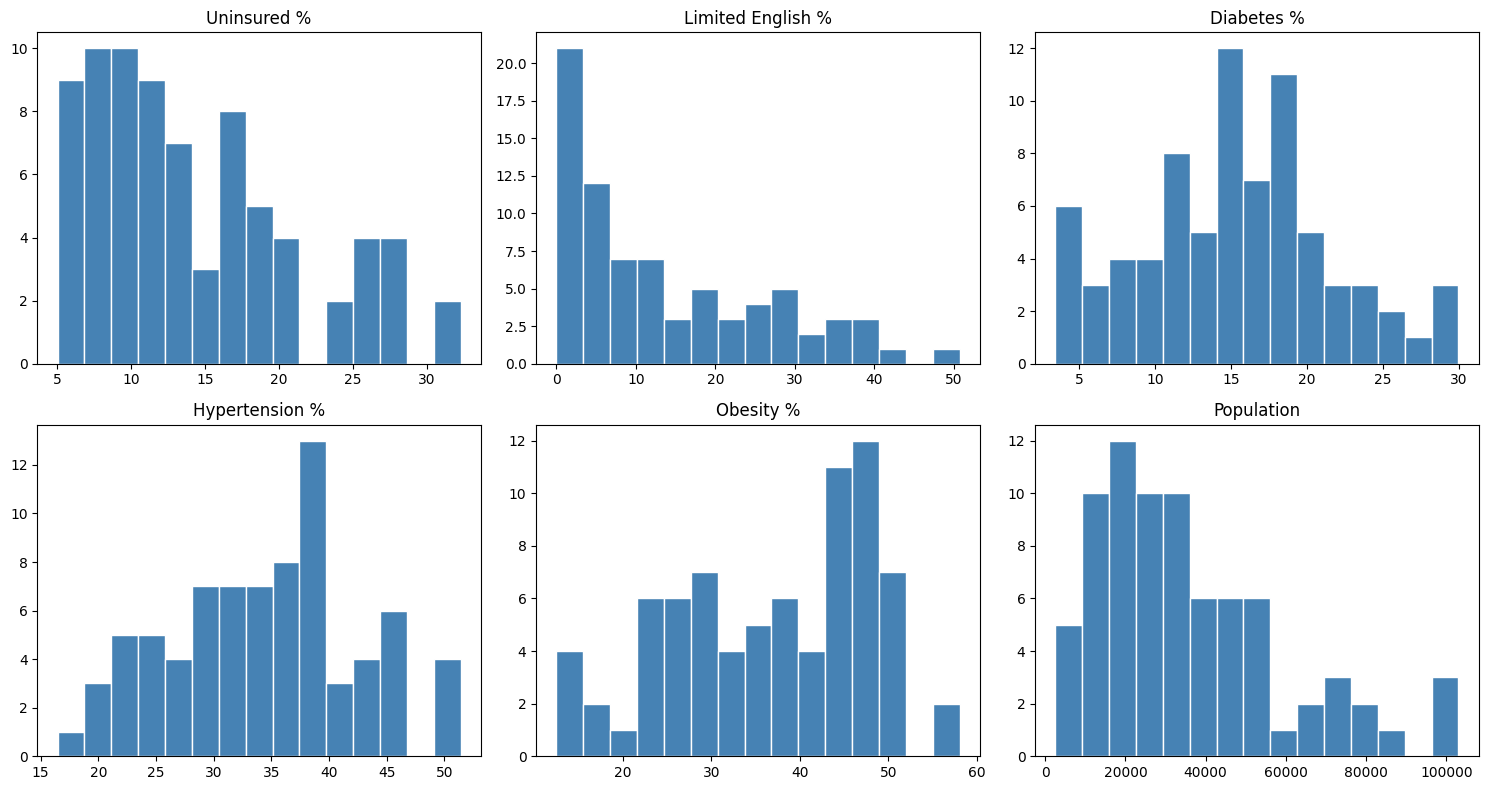

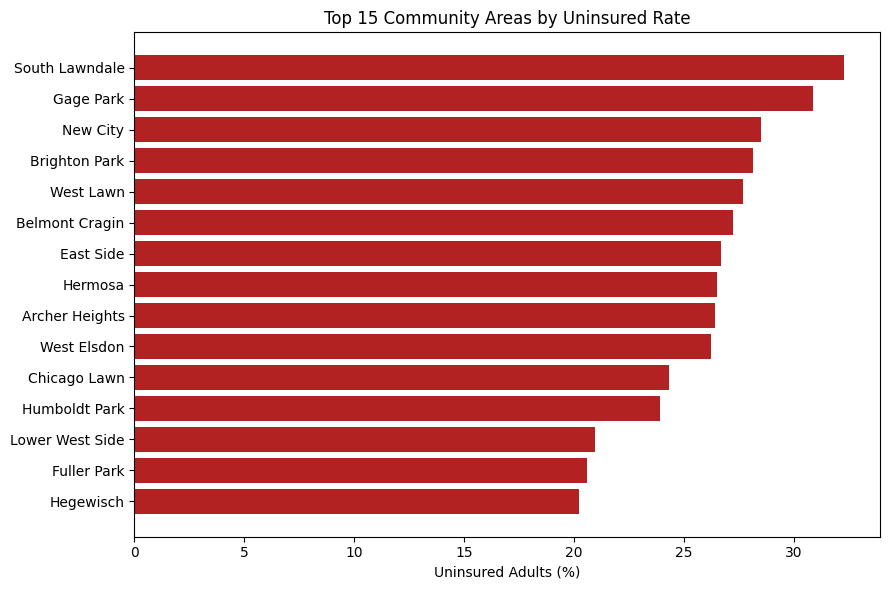

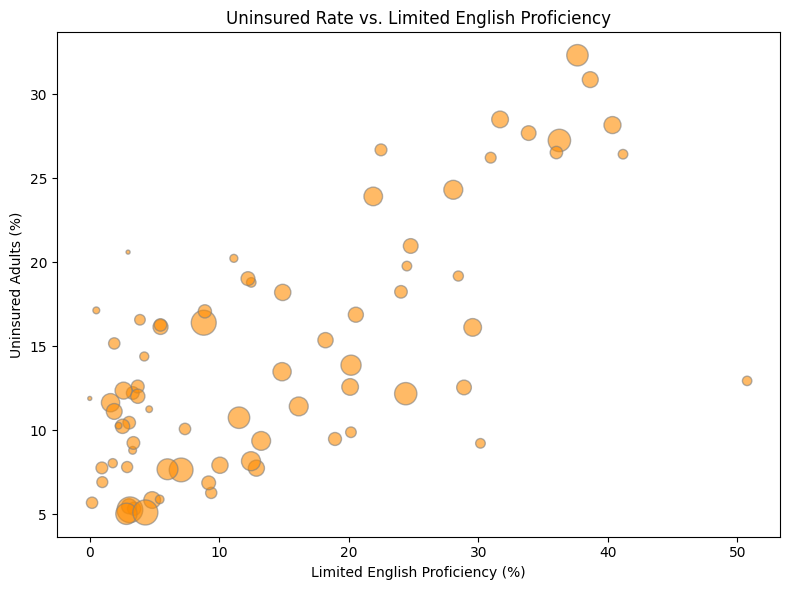

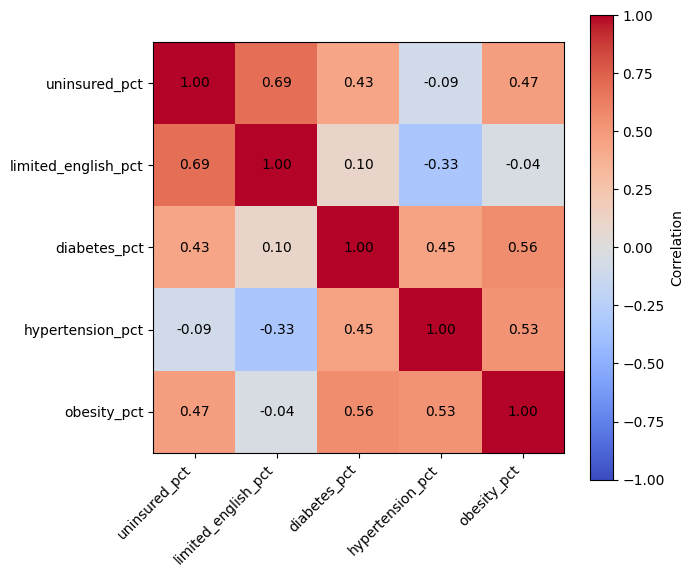

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['uninsured_pct', 'limited_english_pct', 'diabetes_pct',
        'hypertension_pct', 'obesity_pct', 'population']
titles = ['Uninsured %', 'Limited English %', 'Diabetes %',
          'Hypertension %', 'Obesity %', 'Population']

for ax, col, title in zip(axes.flat, cols, titles):
    ax.hist(df[col].dropna(), bins=15, color='steelblue', edgecolor='white')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('histograms_overview.png', dpi=150)
plt.show()

top15 = df.nlargest(15, 'uninsured_pct')
plt.figure(figsize=(9, 6))
plt.barh(top15['community_area'][::-1], top15['uninsured_pct'][::-1], color='firebrick')
plt.xlabel('Uninsured Adults (%)')
plt.title('Top 15 Community Areas by Uninsured Rate')
plt.tight_layout()
plt.savefig('bar_top15_uninsured.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['limited_english_pct'], df['uninsured_pct'], s=df['population']/300,
            alpha=0.6, color='darkorange', edgecolor='gray')
plt.xlabel('Limited English Proficiency (%)')
plt.ylabel('Uninsured Adults (%)')
plt.title('Uninsured Rate vs. Limited English Proficiency')
plt.tight_layout()
plt.savefig('scatter_uninsured_vs_language.png', dpi=150)
plt.show()

corr_cols = ['uninsured_pct', 'limited_english_pct', 'diabetes_pct',
             'hypertension_pct', 'obesity_pct']
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar(label='Correlation')
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

In [7]:
# Clinic Directory
clinics_raw = pd.DataFrame([
    {"clinic_name": "CommunityHealth (Main)", "address": "2611 W Chicago Ave, Chicago, IL 60622"},
    {"clinic_name": "CommunityHealth at Onward House", "address": "5413 Diversey Ave, Chicago, IL 60639"},
    {"clinic_name": "CommunityHealth at Enlace", "address": "2759 S Harding Ave, Chicago, IL 60623"},
    {"clinic_name": "CommunityHealth at Resurrection Project", "address": "4600 S Wood St, Chicago, IL 60609"},
    {"clinic_name": "Care For Friends", "address": "530 W Fullerton Pkwy, Chicago, IL 60614"},
    {"clinic_name": "Chicago Women's Health Center", "address": "1025 W Sunnyside Ave, Chicago, IL 60640"},
    {"clinic_name": "Chi Care", "address": "2711 N Halsted St, Chicago, IL 60614"},
    {"clinic_name": "Chicago Therapy Collective", "address": "5237 N Clark St, Chicago, IL 60640"},
    {"clinic_name": "Hayat Free Community Clinic", "address": "6350 N Maplewood Ave, Chicago, IL 60659"},
    {"clinic_name": "Mercy To Mankind Clinic", "address": "6201 N California Ave, Chicago, IL 60659"},
    {"clinic_name": "IAMACF Free Health Clinic", "address": "2645 W Peterson Ave, Chicago, IL 60659"},
    {"clinic_name": "Norma Jean Sanders Free Clinic", "address": "1049 E 46th St, Chicago, IL 60653"},
    {"clinic_name": "Old Irving Park Community Clinic", "address": "5425 W Addison St, Chicago, IL 60641"},
    {"clinic_name": "The Ark", "address": "6450 N California Ave, Chicago, IL 60645"},
    {"clinic_name": "TAG Oral Care Center", "address": "1040 W Randolph St, Chicago, IL 60607"},
    {"clinic_name": "Washington Park Children's Free Health Clinic", "address": "5350 S Prairie Ave, Chicago, IL 60615"},
    {"clinic_name": "Strength to Love Foundation", "address": "2136 W Belmont Ave, Chicago, IL 60618"},
    {"clinic_name": "Chicago South Side Birth Center", "address": "8301 S South Shore Dr, Chicago, IL 60617"},
])
clinics_raw.to_csv('clinics_addresses.csv', index=False)
clinics_raw

,clinic_name,address
0,CommunityHealth (Main),"2611 W Chicago Ave, Chicago, IL 60622"
1,CommunityHealth at Onward House,"5413 Diversey Ave, Chicago, IL 60639"
2,CommunityHealth at Enlace,"2759 S Harding Ave, Chicago, IL 60623"
3,CommunityHealth at Resurrection Project,"4600 S Wood St, Chicago, IL 60609"
4,Care For Friends,"530 W Fullerton Pkwy, Chicago, IL 60614"
5,Chicago Women's Health Center,"1025 W Sunnyside Ave, Chicago, IL 60640"
6,Chi Care,"2711 N Halsted St, Chicago, IL 60614"
7,Chicago Therapy Collective,"5237 N Clark St, Chicago, IL 60640"
8,Hayat Free Community Clinic,"6350 N Maplewood Ave, Chicago, IL 60659"
9,Mercy To Mankind Clinic,"6201 N California Ave, Chicago, IL 60659"


In [8]:
#Add lat y long columns to the clinics_addresses.cs using geopy
!pip install geopy -q

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="chicago_healthcare_access_project")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

lats, lons = [], []
for addr in clinics_raw['address']:
    location = geocode(addr)
    if location:
        lats.append(location.latitude)
        lons.append(location.longitude)
    else:
        print(f"NO ENCONTRADO: {addr}")
        lats.append(None)
        lons.append(None)

clinics_raw['lat'] = lats
clinics_raw['lon'] = lons
clinics_raw

,clinic_name,address,lat,lon
0,CommunityHealth (Main),"2611 W Chicago Ave, Chicago, IL 60622",41.895408,-87.692425
1,CommunityHealth at Onward House,"5413 Diversey Ave, Chicago, IL 60639",41.931158,-87.761865
2,CommunityHealth at Enlace,"2759 S Harding Ave, Chicago, IL 60623",41.840707,-87.722882
3,CommunityHealth at Resurrection Project,"4600 S Wood St, Chicago, IL 60609",41.810227,-87.670224
4,Care For Friends,"530 W Fullerton Pkwy, Chicago, IL 60614",41.925672,-87.635851
5,Chicago Women's Health Center,"1025 W Sunnyside Ave, Chicago, IL 60640",41.963358,-87.655772
6,Chi Care,"2711 N Halsted St, Chicago, IL 60614",41.931937,-87.648717
7,Chicago Therapy Collective,"5237 N Clark St, Chicago, IL 60640",41.977300,-87.668139
8,Hayat Free Community Clinic,"6350 N Maplewood Ave, Chicago, IL 60659",41.997342,-87.693645
9,Mercy To Mankind Clinic,"6201 N California Ave, Chicago, IL 60659",41.994240,-87.699303


In [9]:
#calculate distance between each community area and the nearest clinic
import numpy as np

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8  # earth ratio in miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

nearest_dist = []
nearest_name = []

for _, row in df.iterrows():
    dists = haversine_miles(row['lat'], row['lon'], clinics_raw['lat'].values, clinics_raw['lon'].values)
    idx = np.argmin(dists)
    nearest_dist.append(round(dists[idx], 2))
    nearest_name.append(clinics_raw['clinic_name'].iloc[idx])

df['dist_to_nearest_clinic_mi'] = nearest_dist
df['nearest_clinic'] = nearest_name

df[['community_area', 'dist_to_nearest_clinic_mi', 'nearest_clinic']].sort_values('dist_to_nearest_clinic_mi', ascending=False).head(10)

,community_area,dist_to_nearest_clinic_mi,nearest_clinic
71,Mount Greenwood,8.27,CommunityHealth at Resurrection Project
72,Morgan Park,7.32,Chicago South Side Birth Center
73,O'Hare,7.03,Old Irving Park Community Clinic
48,West Pullman,6.67,Chicago South Side Birth Center
49,Riverdale,6.49,Chicago South Side Birth Center
69,Beverly,6.46,Washington Park Children's Free Health Clinic
70,Washington Heights,5.54,Chicago South Side Birth Center
50,Hegewisch,5.30,Chicago South Side Birth Center
76,Edison Park,5.02,Old Irving Park Community Clinic
67,Ashburn,4.87,CommunityHealth at Resurrection Project


In [10]:
ADULT_SHARE = 0.62  # Assumption: 62% of the population is between 18 and 64

df['est_adults_18_64'] = (df['population'] * ADULT_SHARE).round(0)
df['est_uninsured_adults'] = (df['est_adults_18_64'] * df['uninsured_pct'] / 100).round(0)

print("Total estimado de adultos sin seguro en la ciudad:", df['est_uninsured_adults'].sum())

df[['community_area', 'population', 'uninsured_pct', 'est_uninsured_adults']].sort_values('est_uninsured_adults', ascending=False).head(10)

Total estimado de adultos sin seguro en la ciudad: 239311.0


,community_area,population,uninsured_pct,est_uninsured_adults
23,South Lawndale,71402,32.306265,14302.0
10,Belmont Cragin,78151,27.239850,13199.0
17,Austin,96753,16.397925,9837.0
62,Chicago Lawn,55789,24.305124,8407.0
15,Humboldt Park,53832,23.910283,7980.0
53,Brighton Park,45141,28.154257,7880.0
57,New City,43510,28.489171,7685.0
59,Gage Park,39439,30.856499,7545.0
11,West Ridge,77139,12.177971,5824.0
61,West Lawn,33543,27.676870,5756.0


In [11]:
#Normalize each factor to a 0-1 scale so they're comparable (can't mix % and miles directly)
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

#Combine diabetes, hypertension, and obesity into one "chronic disease burden" score
df['chronic_burden'] = df[['diabetes_pct', 'hypertension_pct', 'obesity_pct']].mean(axis=1)

# Normalize the four factors that will feed into the priority index
df['z_uninsured_volume'] = normalize(df['est_uninsured_adults'])
df['z_distance']         = normalize(df['dist_to_nearest_clinic_mi'])
df['z_chronic_burden']   = normalize(df['chronic_burden'])
df['z_language']         = normalize(df['limited_english_pct'])

# Assign weights: prioritize raw volume of need and access gap over other factors
WEIGHTS = {
    'z_uninsured_volume': 0.40,
    'z_distance':         0.30,
    'z_chronic_burden':   0.20,
    'z_language':         0.10,
}

# Weighted sum = the final priority score per community area
df['priority_index'] = sum(df[col] * w for col, w in WEIGHTS.items())

# Rank all 77 areas, highest priority first
ranked = df.sort_values('priority_index', ascending=False).reset_index(drop=True)
top10 = ranked.head(10)

top10[['community_area', 'population', 'uninsured_pct', 'est_uninsured_adults',
       'dist_to_nearest_clinic_mi', 'chronic_burden', 'limited_english_pct', 'priority_index']]

,community_area,population,uninsured_pct,est_uninsured_adults,dist_to_nearest_clinic_mi,chronic_burden,limited_english_pct,priority_index
0,South Lawndale,71402,32.306265,14302.0,0.47,26.174417,37.650306,0.571437
1,Belmont Cragin,78151,27.239850,13199.0,0.33,29.306614,36.255914,0.552765
2,Chicago Lawn,55789,24.305124,8407.0,2.96,35.729579,28.066793,0.540318
3,Austin,96753,16.397925,9837.0,2.56,36.022872,8.804414,0.529978
4,West Lawn,33543,27.676870,5756.0,4.04,34.064932,33.884482,0.505767
5,Gage Park,39439,30.856499,7545.0,1.69,37.085264,38.638064,0.498571
6,Ashburn,41280,18.200379,4658.0,4.87,35.243223,14.900757,0.475698
7,Brighton Park,45141,28.154257,7880.0,1.55,31.186693,40.352971,0.467626
8,West Pullman,25940,12.605522,2027.0,6.67,37.263888,3.708943,0.458992
9,Mount Greenwood,18633,6.918400,799.0,8.27,33.075826,0.976591,0.450642


In [12]:
top10 = ranked.head(10)

#What % of the city represents those 10 neighborhoods?
top10_uninsured = top10['est_uninsured_adults'].sum()
city_uninsured = df['est_uninsured_adults'].sum()
pct_of_city = round(100 * top10_uninsured / city_uninsured, 1)

print(f"Top 10 priority areas {top10_uninsured:.0f} de {city_uninsured:.0f} no insured adults estimated = {pct_of_city}%")

avg_lep_top10 = top10['limited_english_pct'].mean()
avg_lep_city = df['limited_english_pct'].mean()
print(f"Top 10 limited english: {avg_lep_top10:.1f}% vs. city average: {avg_lep_city:.1f}%")

beyond_3mi = (top10['dist_to_nearest_clinic_mi'] > 3).sum()
print(f"Out of the top 10, {beyond_3mi} are 3 miles away from the nearest clinic")

Top 10 priority areas 74410 de 239311 no insured adults estimated = 31.1%
Top 10 limited english: 24.3% vs. city average: 14.0%
Out of the top 10, 4 are 3 miles away from the nearest clinic


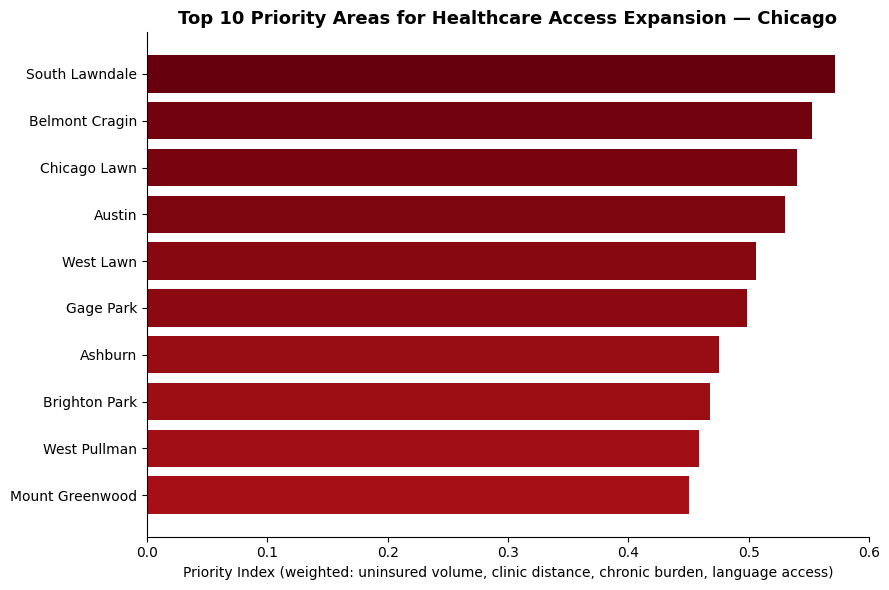

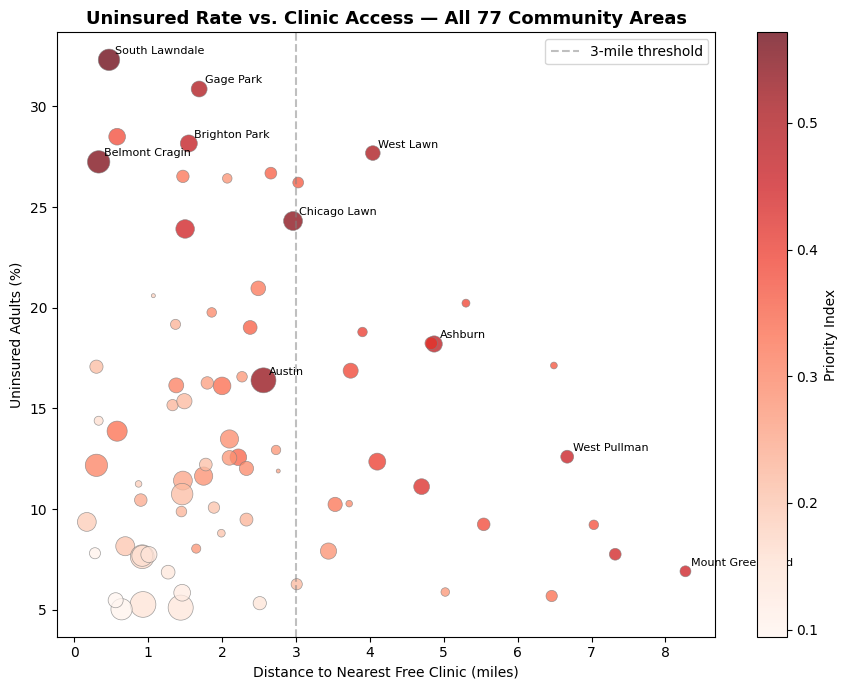

In [13]:
import matplotlib.pyplot as plt

# Chart 1: bar chart: Top 10 priority areas
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.Reds(top10['priority_index'] / top10['priority_index'].max() * 0.6 + 0.4)
ax.barh(top10['community_area'][::-1], top10['priority_index'][::-1], color=colors[::-1])
ax.set_xlabel('Priority Index (weighted: uninsured volume, clinic distance, chronic burden, language access)')
ax.set_title('Top 10 Priority Areas for Healthcare Access Expansion — Chicago', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart_top10_priority.png', dpi=150)
plt.show()

# Chart 2: scatter of uninsured rate vs. distance to clinic, for all 77 areas
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(ranked['dist_to_nearest_clinic_mi'], ranked['uninsured_pct'],
                 s=ranked['population']/300, c=ranked['priority_index'], cmap='Reds',
                 alpha=0.75, edgecolors='gray', linewidth=0.5)
for _, row in top10.iterrows():
    ax.annotate(row['community_area'], (row['dist_to_nearest_clinic_mi'], row['uninsured_pct']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Distance to Nearest Free Clinic (miles)')
ax.set_ylabel('Uninsured Adults (%)')
ax.set_title('Uninsured Rate vs. Clinic Access — All 77 Community Areas', fontsize=13, fontweight='bold')
ax.axvline(3, color='gray', linestyle='--', alpha=0.5, label='3-mile threshold')
ax.legend()
plt.colorbar(sc, label='Priority Index')
plt.tight_layout()
plt.savefig('chart_scatter_access_gap.png', dpi=150)
plt.show()

In [14]:
!pip install folium -q
import folium

# Estimated center of Chicago
m = folium.Map(location=[41.85, -87.68], zoom_start=11, tiles='CartoDB positron')

# Top 10 priority areas (form the list)
top10_names = top10['community_area'].tolist()

# dot for ea neighborhood
for _, row in ranked.iterrows():
    is_priority = row['community_area'] in top10_names

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6 + (row['est_uninsured_adults'] / 1500),  # Volume of uninsured population
        color='darkred' if is_priority else 'gray',
        fill=True,
        fill_color='red' if is_priority else 'lightgray',
        fill_opacity=0.75 if is_priority else 0.35,
        popup=folium.Popup(
            f"<b>{row['community_area']}</b><br>"
            f"Uninsured: {row['uninsured_pct']:.1f}%<br>"
            f"Limited English: {row['limited_english_pct']:.1f}%<br>"
            f"Distance to clinic: {row['dist_to_nearest_clinic_mi']} mi<br>"
            f"{'⭐ TOP 10 PRIORITY' if is_priority else ''}",
            max_width=250
        )
    ).add_to(m)

# Add 18 clinics with different markers
for _, row in clinics_raw.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.Icon(color='blue', icon='plus-sign'),
        popup=row['clinic_name']
    ).add_to(m)

m.save('chicago_access_map.html')
m

In [15]:
import branca.colormap as cm

colormap = cm.LinearColormap(colors=['white', 'orange', 'darkred'],
                               vmin=ranked['limited_english_pct'].min(),
                               vmax=ranked['limited_english_pct'].max())

m2 = folium.Map(location=[41.85, -87.68], zoom_start=11, tiles='CartoDB positron')

for _, row in ranked.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=7,
        color=colormap(row['limited_english_pct']),
        fill=True,
        fill_color=colormap(row['limited_english_pct']),
        fill_opacity=0.8,
        popup=f"{row['community_area']}: {row['limited_english_pct']:.1f}% limited English"
    ).add_to(m2)

colormap.caption = 'Limited English Proficiency (%)'
colormap.add_to(m2)
m2.save('chicago_language_map.html')
m2